## ДЗ №3 Двухуровневый пайплайн
#### В этой домашке вам предстоит написать с нуля двустадийную рекомендательную систему. 

#### Дата выдачи: 10.03.25

#### Мягкий дедлайн: 31.03.25 23:59 MSK

#### Жесткий дедлайн: 7.04.25 23:59 MSK

### Описание
Это творческое задание, в котором вам необходимо реализовать полный цикл построения рекомендательной системы: реализовать кандидат генераторов, придумать и собрать признаки, обучить итоговый ранкер и заинференсить модели на всех пользователей.

Вам предоставляется два набора данных: `train.csv` и `test.csv` 

In [1]:
import pandas as pd
import numpy as np
from typing import List, Optional, Union

from collections import OrderedDict, Counter
import tqdm
import random
import torch

import os
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import init_seed
import numpy as np
from recbole.model.sequential_recommender.bert4rec import BERT4Rec
from recbole.trainer import Trainer
from recbole.data.interaction import Interaction
import tqdm


import warnings
warnings.filterwarnings('ignore')

In [2]:
def ndcg_metric(gt_items, predicted):
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)
    if rank_dcg == 0.0:
        return 0.0
    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])
    if ideal_dcg == 0.0:
        return 0.0
    ndcg_ = rank_dcg / ideal_dcg
    return ndcg_


def dcg(scores):
    return np.sum(np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)),
                  dtype=np.float64)

def recall_metric(gt_items, predicted):    
    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / n_gt

def evaluate_recommender(df, model_preds, gt_col='test_interactions', topn=10):    
    metric_values = []
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
    return {'ndcg':np.mean([x[0] for x in metric_values]),
            'recall':np.mean([x[1] for x in metric_values])}

In [3]:
# скачиваем данные
# если из этой ячейки не получается, то вот ссылка на папку https://drive.google.com/drive/folders/1HT0Apm8Jft0VPLJtdBBUGu9s1M7vZcoJ?usp=drive_link

# !pip3 install gdown


# import gdown
# train
# url = "https://drive.google.com/file/d/1-CcS22-UpTJeNcFlA0dVLrEQn8jnI0d-/view?usp=drive_link"
# output = 'train_part.csv'
# gdown.download(url, output, quiet=False)

# test
# url = "https://drive.google.com/file/d/11iz3xDh0IIoEIBY0dyRSvByY3qfiT3BG/view?usp=drive_link"
# output = 'test_part.csv'
# gdown.download(url, output, quiet=False)

# items
# url = "https://drive.google.com/file/d/1chCmpiCKJRjdqNftHc-t2ALl3qbAp2G8/view?usp=drive_link"
# output = 'items.csv'
# gdown.download(url, output, quiet=False)

# users
# url = "https://drive.google.com/file/d/1zl2jWMdUhc-IMakHlihQhJ5PGGZm9-_O/view?usp=drive_link"
# output = 'users.csv'
# gdown.download(url, output, quiet=False)

In [34]:
train_df = pd.read_csv('train_part.csv')
print(train_df.shape)
train_df['last_watch_dt'] = pd.to_datetime(train_df['last_watch_dt'])
train_df.head()

(4866956, 6)


,user_id,item_id,last_watch_dt,total_dur,watched_pct,target
0,310745,13373,2021-03-13,4485,98.0,1
1,952323,15997,2021-03-13,7507,100.0,1
2,889459,11460,2021-03-13,60,0.0,0
3,854016,11237,2021-03-13,5381,98.0,1
4,307257,9132,2021-03-13,5814,100.0,1


In [35]:
test_df = pd.read_csv('test_part.csv')
test_df['last_watch_dt'] = pd.to_datetime(test_df['last_watch_dt'])
print(test_df.shape)

(608467, 6)


In [36]:
# оставим только тех юзеров и те айтемы, что есть в трейне
train_users = train_df['user_id'].unique()
train_items = train_df['item_id'].unique()

test_df = test_df[test_df['user_id'].isin(train_users)]
test_df = test_df[test_df['item_id'].isin(train_items)]

In [37]:
# закодируем айтемы и юзеры 
from sklearn.preprocessing import LabelEncoder

user_le = LabelEncoder()
item_le = LabelEncoder()

train_df['user_id'] = user_le.fit_transform(train_df['user_id'])
train_df['item_id'] = item_le.fit_transform(train_df['item_id'])

test_df['user_id'] = user_le.transform(test_df['user_id'])
test_df['item_id'] = item_le.transform(test_df['item_id'])

In [38]:
train_df['user_id'].nunique(), train_df['user_id'].max(), train_df['item_id'].nunique(), train_df['item_id'].max()

(880421, 880420, 15418, 15417)



### 1 Этап. Модели первого уровня. (max 3 балла)
В этом этапе вам необходимо разделить `train` датасет на 2 части: для обучения моделей первого уровня и для их валидации. Единственное условие для разбиения – разбивать нужно по времени. Данные для обучение будем называть `train_stage_1`, данные для валидации `valid_stage_1`. Объемы этих датасетов вы определяет самостоятельно. 

Для начала нам нужно отобрать кандидатов при помощи легких моделей. Необходимо реализовать 3 типа моделей:
1. Любая эвристическая(алгоритмичная) модель на ваш выбор **(0.5 балл)**
2. Любая матричная факторизация на ваш выбор **(1 балл)**
3. Любая нейросетевая модель на ваш выбор **(1 балла)**

Не забудьте использовать скор каждой модели, как признак!



In [10]:
# разобъем трейн на 2 части, в валидационную выборке оставим последние 30 дней
val_ind = train_df['last_watch_dt'].max() - pd.Timedelta(days=30)
train_stage_1 = train_df[train_df['last_watch_dt'] <= val_ind]
valid_stage_1 = train_df[train_df['last_watch_dt'] > val_ind]
print(f'В валидационную выборку попало {round(valid_stage_1.shape[0] / train_df.shape[0] * 100, 2)}% всего трейна')

В валидационную выборку попало 31.69% всего трейна


In [11]:
train_stage_1['last_watch_dt'] = train_stage_1['last_watch_dt'].astype(str)
valid_stage_1['last_watch_dt'] = valid_stage_1['last_watch_dt'].astype(str)
test_df['last_watch_dt'] = test_df['last_watch_dt'].astype(str)

In [12]:
train_grouped = train_stage_1.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id, 
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

validate_grouped = valid_stage_1.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id, 
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
validate_grouped.rename({0:'validate_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)


joined = train_grouped.merge(validate_grouped).merge(test_grouped)
joined.head()

,user_id,train_interactions,validate_interactions,test_interactions
0,2,"[(2468, 2021-06-03)]","[(3470, 2021-07-22), (9059, 2021-07-23), (8892...","[(130, 2021-08-13), (9523, 2021-08-16), (43, 2..."
1,17,"[(9564, 2021-03-20), (14919, 2021-03-28), (791...","[(3517, 2021-07-26)]","[(13502, 2021-08-18), (12837, 2021-08-18)]"
2,22,"[(4418, 2021-06-09), (624, 2021-06-12), (11542...","[(6744, 2021-07-30), (15384, 2021-08-11), (280...","[(14325, 2021-08-13), (10467, 2021-08-13), (10..."
3,41,"[(12914, 2021-07-01), (7046, 2021-07-01), (971...","[(9786, 2021-07-16), (1452, 2021-07-16), (6148...","[(15328, 2021-08-15), (14743, 2021-08-17), (14..."
4,43,"[(9217, 2021-03-28), (5755, 2021-05-12), (2850...","[(3757, 2021-07-22), (3574, 2021-07-22), (4155...","[(13, 2021-08-16)]"


In [13]:
# оставляю данные только по тем юзерам, которые есть и в трейне, и в валидации, и в тесте
train_stage_1 = train_stage_1[train_stage_1['user_id'].isin(joined['user_id'])].reset_index(drop=True)
valid_stage_1 = valid_stage_1[valid_stage_1['user_id'].isin(joined['user_id'])].reset_index(drop=True)
test_df = test_df[test_df['user_id'].isin(joined['user_id'])].reset_index(drop=True)

# оставлю только 5000 человек, иначе очень долго код отрабатывает
N = 5_000
random_users = joined.sample(N, random_state=42)['user_id'].to_numpy()
train_stage_1 = train_stage_1[train_stage_1['user_id'].isin(random_users)].reset_index(drop=True)
valid_stage_1 = valid_stage_1[valid_stage_1['user_id'].isin(random_users)].reset_index(drop=True)
test_df = test_df[test_df['user_id'].isin(random_users)].reset_index(drop=True)
joined = joined[joined['user_id'].isin(random_users)].reset_index(drop=True)

`Реализую следущие модели:`

1. TopPopular
2. iALS
3. BERT4Rec


In [7]:
# 1. эвристическая модель - TopPopular
class TopPopular:
    def __init__(self):
        self.trained = False

    def fit(self, df, col='train_interactions'):
        self.users = df['user_id']
        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1
        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        self.recommenations = [x[0] for x in counts]
        self.trained = True


    def predict(self, df, topn=100)  -> List[np.ndarray]:
        assert self.trained
        self.topn = topn
        self.all_recs = []
        for _, row in df.iterrows():
            user_recs = []
            user_interactions = set([x[0] for x in row['train_interactions']])
            for elem in self.recommenations:
                if elem not in user_interactions:
                    user_recs.append(elem)
                if len(user_recs) == topn:
                    break
            self.all_recs.append(user_recs)
        return pd.DataFrame(self.all_recs)

    def get_score(self, user_id, item_id):
        recs2user = pd.DataFrame(self.all_recs)
        recs2user['user_id'] = self.users
        recs2user = recs2user[recs2user['user_id'] == user_id].drop(columns=['user_id'])
        if len(recs2user) > 0:
            for i in range(self.topn):
                if recs2user[i].iloc[0] == item_id:
                    return i + 1
            return self.topn + 1  # если среди рекомендация айтем не найден
        else:
            raise Exception(f'User {user_id} не найден!')

In [17]:
toppop = TopPopular()
toppop.fit(joined, col='train_interactions')
toppopular_recs = toppop.predict(joined)

In [18]:
toppop_recommendations = pd.DataFrame({'user_id': joined['user_id'], 'toppopular_recs': pd.DataFrame(toppopular_recs).apply(lambda row: list(row), axis=1)})
joined = toppop_recommendations.merge(joined, how='inner', on='user_id')
evaluate_recommender(joined, gt_col='validate_interactions', model_preds='toppopular_recs')

{'ndcg': 0.5273615125552121, 'recall': 0.3159170158004909}

In [19]:
joined.head(1)

,user_id,toppopular_recs,train_interactions,validate_interactions,test_interactions
0,43,"[9712, 12914, 9059, 3859, 3470, 130, 4552, 246...","[(9217, 2021-03-28), (5755, 2021-05-12), (2850...","[(3757, 2021-07-22), (3574, 2021-07-22), (4155...","[(13, 2021-08-16)]"


In [20]:
# user_id == 43
toppopular_recs.head(1)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,9712,12914,9059,3859,3470,130,4552,2468,8036,12088,...,15006,10005,10177,12245,5053,11878,11945,8193,14324,6007


In [23]:
# примеры работы функции get_score
print(toppop.get_score(user_id=43, item_id=9712))  # top-1
print(toppop.get_score(user_id=43, item_id=12914))  # top-2
print(toppop.get_score(user_id=43, item_id=14324))  # top-99
print(toppop.get_score(user_id=43, item_id=6007))  # top-100
print(toppop.get_score(user_id=43, item_id=100500))  # top-100+ -> 101

1
2
99
100
101


In [9]:
# 2. матричная факторизация - iALS

class iALS:
    def __init__(self, n_factors: int = 100, alpha: float = 1.0, reg_coef = 0.01):
        self.n_factors = n_factors
        self.alpha = alpha
        self.reg_coef = reg_coef    
        self.user_factors = None  # матрица X
        self.item_factors = None  # матрица Y

    def fit(self, interactions: np.ndarray, n_iterations: int=1):
        self.users = interactions.index.to_numpy()
        self.interactions = interactions.values
        
        n_users, n_items = self.interactions.shape
        self.user_factors = np.random.normal(size=(n_users, self.n_factors))
        self.item_factors = np.random.normal(size=(n_items, self.n_factors))

        YtY = self.item_factors.T @ self.item_factors
        XtX = self.user_factors.T @ self.user_factors
        
        for iter in tqdm.tqdm(range(n_iterations)):
            for u in range(n_users):
                u_items = self.interactions[u]
                p_u = np.where(u_items > 0, 1, 0)
                c_ii = 1 + self.alpha * u_items
                C = np.diag(c_ii)
                x_u = np.linalg.inv(YtY + self.item_factors.T @ (C - np.eye(C.shape[0])) @ self.item_factors + self.reg_coef * np.eye(YtY.shape[0])) @ self.item_factors.T @ C @ p_u
                self.user_factors[u] = x_u
            
            for i in range(n_items):
                u_users = self.interactions[:, i]
                p_i = np.where(u_users > 0, 1, 0)
                c_uu = 1 + self.alpha * u_users
                C = np.diag(c_uu)
                y_i = np.linalg.inv(XtX + self.user_factors.T @ (C - np.eye(C.shape[0])) @ self.user_factors + self.reg_coef * np.eye(XtX.shape[0])) @ self.user_factors.T @ C @ p_i
                self.item_factors[i] = y_i

    def predict(self, top_k: int = 100):
        # возвращает top-k айтемов для каждого юзера(айтемы с которыми юзер взаимодействовал не должны попасть в рекомендации)
        self.top_k = top_k
        predictions = self.user_factors @ self.item_factors.T
        self.recs = np.zeros((self.user_factors.shape[0], self.top_k))
        for u in range(predictions.shape[0]):
            # проставим -inf тем айтемам, с которыми юзер уже взаимодействовал
            predictions[u][self.interactions[u].nonzero()] = -np.inf
            self.recs[u] = np.argpartition(predictions[u], -self.top_k)[-self.top_k:]
        self.recs = self.recs.astype(int)
        return self.recs # shape ~ [n_users, top_k]
    
    def get_score(self, user_id, item_id):
        recs2user = pd.DataFrame(self.recs)
        recs2user['user_id'] = self.users
        recs2user = recs2user[recs2user['user_id'] == user_id].drop(columns=['user_id'])
        if len(recs2user) > 0:
            for i in range(self.top_k):
                if recs2user[i].iloc[0] == item_id:
                    return i + 1
            return self.top_k + 1  # если среди рекомендация айтем не найден
        else:
            raise Exception(f'User {user_id} не найден!')
        
        
       

def df_to_matrix(df: pd.DataFrame) -> np.ndarray:
    df['was_action'] = 1  # сделал константный столбец, чтобы легко перевести в матрице интеракций
    result = df.pivot_table(values='was_action', index='user_id', columns='item_id').fillna(0)
    return result #shape ~ [n_users, n_items]

In [25]:
train_interactions = df_to_matrix(train_stage_1)

In [26]:
als_model = iALS()
als_model.fit(train_interactions, n_iterations=5)
my_als_pred = pd.DataFrame(als_model.predict())

100%|██████████| 5/5 [1:32:05<00:00, 1105.10s/it]


In [27]:
als_recommendations = pd.DataFrame({'user_id': joined['user_id'].to_numpy(), 'als_recs': my_als_pred.apply(lambda row: list(row), axis=1)})
joined = joined.merge(als_recommendations)
evaluate_recommender(joined, gt_col='validate_interactions', model_preds='als_recs')

{'ndcg': 0.00985530466756948, 'recall': 0.0027858736899399983}

In [28]:
# user_id == 43
my_als_pred.head(1)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,3955,830,245,4828,5318,5073,388,2395,3235,4815,...,2539,3957,3790,3262,5577,5589,1387,417,1463,685


In [29]:
# примеры работы функции get_score
print(als_model.get_score(user_id=43, item_id=3955))     # top-1
print(als_model.get_score(user_id=43, item_id=830))     # top-2
print(als_model.get_score(user_id=43, item_id=1463))     # top-99
print(als_model.get_score(user_id=43, item_id=685))       # top-100
print(als_model.get_score(user_id=43, item_id=100500))  # top-100+ -> 101

1
2
99
100
101


In [ ]:
# нейросетевая модель - BERT4Rec

In [11]:
class BertRec:
    def __init__(self, df, user_id_col, item_id_col, datetime_col, dataset_name='test_dataset'):
        self.dataset_name = dataset_name

        # предобработаем датафрейм под единый тип
        df = df.rename(columns={user_id_col: 'user_id', item_id_col: 'item_id', datetime_col: 'timestamp'})
        df['timestamp'] = pd.to_datetime(df['timestamp']).view('int64') // 10**9
        df = df[['user_id', 'item_id', 'timestamp']]
        self.toppop_items = df['item_id'].value_counts().head(100).index.to_numpy()
        self.user_ids = df['user_id'].unique()
        df.columns = ['user_id:token', 'item_id:token', 'timestamp:float']
        

        # сохраним в директорию dataset
        directory = f'dataset/{dataset_name}'
        filepath = f'dataset/{dataset_name}/{dataset_name}.inter'
        os.makedirs(directory, exist_ok=True)
        df.to_csv(filepath, index=False)

    def fit(self, config_dict=None):
        if config_dict == None:
            config_dict = {
            'data_path': 'dataset/',
            'dataset': f'{self.dataset_name}',
            'data_file': f'{self.dataset_name}.inter',
            'field_separator': ',',
            'model': 'BERT4Rec',
            'USER_ID_FIELD': 'user_id',
            'ITEM_ID_FIELD': 'item_id',
            'TIME_FIELD': 'timestamp',
            'load_col': {'inter': ['user_id', 'item_id', 'timestamp']},
            'reproducibility': False,
            'seed': 42,
            'epochs': 10,
            'train_batch_size': 256,
            'eval_batch_size': 512,
            'max_seq_length': 100,  # Максимальная длина последовательности
            'train_neg_sample_args': None,
            'hidden_size': 256,
            'inner_size': 512,
            'n_layers': 2,
            'n_heads': 4,
            'hidden_dropout_prob': 0.3,
            'attn_dropout_prob': 0.3,
            'hidden_act': 'gelu',
            'loss_type': 'CE',
            'metrics': ['Recall', 'MRR', 'NDCG'],
            'topk': 100,  # Количество рекомендаций
            'valid_metric': 'Recall@100',
            'eval_args': {
                'split': {'RS': [0.8, 0.1, 0.1]},
                'group_by': 'user',
                'order': 'TO',
                'mode': 'full'
            }
        }
        init_seed(config_dict['seed'], reproducibility=True)
        config = Config(config_dict=config_dict)
        self.dataset = create_dataset(config)
        
        train_data, valid_data, test_data = data_preparation(config, self.dataset)

        model = BERT4Rec(config, self.dataset)
        trainer = Trainer(config, model)
        metrics = trainer.fit(
            train_data, 
            valid_data,
            saved=True,
            show_progress=True
        )
        self.model = model
        self.metrics = metrics
        
    def predict(self, topk=100):
        self.model.eval()
        self.topk = topk
        self.bert_recs = []
        
        # итерируемся по юзерам
        for user_id in tqdm.tqdm(self.user_ids):
            str_user_id = str(user_id)
            internal_uid = self.dataset.token2id('user_id', str_user_id)  # переходим к пространству изначальных идентификаторов
            user_interactions = self.dataset.inter_feat[self.dataset.inter_feat['user_id'] == internal_uid]
            item_ids = user_interactions[self.dataset.iid_field].numpy()
            if len(item_ids) > self.dataset.max_item_list_len:  # в модели выставил максимальную длину последовательности = 100, если больше, то берем только последние 100 айтемов
                item_ids = item_ids[-self.dataset.max_item_list_len:]
            seq_length = len(item_ids)
            user_seq = {
                        'item_id_list': torch.LongTensor(item_ids).unsqueeze(0),
                        'item_length': torch.LongTensor([seq_length])
                    }
            inter = Interaction(user_seq)

            with torch.no_grad():
                if len(item_ids) > 0:  # если есть данные по юзеру в обучающей выборке
                    scores = self.model.full_sort_predict(inter).cpu().numpy().squeeze()  # считаем предсказание по данным айтемам
                    scores[item_ids] = -np.inf  # делаем прогноз -inf для тех айтемов, с которыми юзер уже взаимодействовал
                    topk_idx = np.argpartition(-scores, topk)[:topk]  
                    topk_items = topk_idx[np.argsort(-scores[topk_idx])]  # берем топ-100 айтемов с наибольшим скором
                    top_items = np.array([self.dataset.id2token('item_id', item) for item in topk_items])  # переходим к изначальным идентификаторам айтемов
                    top_items = np.array([int(item) if item != '[PAD]' else self.toppop_items[0] for item in top_items])  # переведу в инты + уберу ПАДы (заменях их на самый популярный айтем)
                    self.bert_recs.append((user_id, top_items))  # добавляем пару юзер-рекомендуемые айтемы в итоговый список
                else:
                    self.bert_recs.append((user_id, self.toppop_items))  # если нет сведений о юзере - рекомендую топ-100 айтемом по популярности
            self.bert_recs_df = pd.DataFrame(self.bert_recs, columns=['user_id', 'recs'])
            self.bert_recs_df = pd.concat([self.bert_recs_df['user_id'], self.bert_recs_df['recs'].apply(pd.Series)], axis=1).sort_values(by='user_id').reset_index(drop=True)
            
        return self.bert_recs_df


    def get_score(self, user_id, item_id):
        recs2user = self.bert_recs_df[self.bert_recs_df['user_id'] == user_id].drop(columns=['user_id'])
        if len(recs2user) > 0:
            for i in range(self.topk):
                if recs2user[i].iloc[0] == item_id:
                    return i + 1
            return self.topk + 1  # если среди рекомендация айтем не найден
        else:
            raise Exception(f'User {user_id} не найден!')

In [31]:
bert = BertRec(train_stage_1, user_id_col='user_id', item_id_col='item_id', datetime_col='last_watch_dt', dataset_name='recsys_hw3')
bert.fit()

Evaluate   : 100%|██████████████████████████████████████████████████| 13/13 [00:02<00:00,  5.43it/s]


In [ ]:
bert_recs = bert.predict(topk=100)

100%|██████████| 5000/5000 [07:51<00:00, 10.61it/s]


In [33]:
print(bert_recs.shape)
bert_recs.head()

(5000, 101)


,user_id,0,1,2,3,4,5,6,7,8,...,90,91,92,93,94,95,96,97,98,99
0,43,9059,9712,3470,3859,10956,130,12914,12088,14324,...,15006,14962,11063,7642,14669,10643,15311,11916,10444,852
1,82,5706,7303,6802,2937,6311,6487,12341,11513,7056,...,2525,7315,12277,9217,6928,7063,12068,7645,12373,11341
2,456,3607,13235,11165,3393,1548,12396,11349,5262,6473,...,1625,2794,9040,9715,5993,1153,2709,4785,2656,12033
3,534,5955,7338,9308,130,12514,7855,11961,9059,12914,...,5755,2652,1478,607,13485,1349,7767,11521,12160,9298
4,764,9712,12914,14266,9059,3859,3470,130,4552,2468,...,3264,4906,5064,15006,10177,10005,12245,5053,11878,11945


In [34]:
# примеры работы функции get_score
print(bert.get_score(user_id=43, item_id=9059))     # top-1
print(bert.get_score(user_id=43, item_id=9712))     # top-2
print(bert.get_score(user_id=43, item_id=10444))     # top-99
print(bert.get_score(user_id=43, item_id=852))       # top-100
print(bert.get_score(user_id=43, item_id=100500))  # top-100+ -> 101

1
2
99
100
101


In [44]:
bert4rec_recommendations = pd.DataFrame({'user_id': bert_recs['user_id'].to_numpy(), 'bert_recs': bert_recs.drop('user_id', axis=1).apply(lambda row: list(row), axis=1)})
joined = joined.merge(bert4rec_recommendations)
evaluate_recommender(joined, gt_col='validate_interactions', model_preds='bert_recs')

{'ndcg': 0.45763847281549724, 'recall': 0.26076258450928264}

In [ ]:
my_heuristic_model = toppop
my_matrix_factorization = als_model
my_neural_network = bert

Каждая модель должна уметь:
1) для пары user_item предсказывать скор релевантности (масштаб скора не важен), важно обработать случаи, когда модель не можеn проскорить пользователя или айтем, вместо этого вернуть какое-то дефолтное значение
2) для всех пользователей вернуть top-k самых релевантных айтемов (тут вам скоры не нужны)


Дополнительно можно провести анализ кандидат генератов, измерить насколько различные айтемы они рекомендуют, например с помощью таких метрик как: [Ranked based overlap](https://github.com/changyaochen/rbo) или различные вариации [Diversity](https://github.com/MaurizioFD/RecSys2019_DeepLearning_Evaluation/blob/master/Base/Evaluation/metrics.py#L289). **(1 балл)**

In [ ]:
from rbo import RankingSimilarity

tp_vs_mf_rbo = []
mf_vs_nn_rbo = []
tp_vs_nn_rbo = []
for i in range(joined.shape[0]):
    tp_recs = joined.iloc[i]['toppopular_recs']
    mf_recs = joined.iloc[i]['als_recs']
    nn_recs = joined.iloc[i]['bert_recs']

    tp_vs_mf_rbo.append(RankingSimilarity(tp_recs, mf_recs).rbo())
    mf_vs_nn_rbo.append(RankingSimilarity(mf_recs, nn_recs).rbo())
    tp_vs_nn_rbo.append(RankingSimilarity(tp_recs, nn_recs).rbo())

print(f'{np.mean(tp_vs_mf_rbo).round(3)}')  # рекомендации TopPopular и iALS
print(f'{np.mean(mf_vs_nn_rbo).round(3)}')  # рекомендации iALS и Bert4Rec
print(f'{np.mean(tp_vs_nn_rbo).round(3)}')  # рекомендации TopPopular и Bert4Rec 

0.0
0.002
0.407


`Рекомендации TopPopular и iALS, а также iALS и Bert4Rec полностью различны. В то время как рекомендации TopPopular и Bert4Rec имеют общие элементы (фильмы).`

`Теперь посчитаем Diversity`

In [53]:
class _Metrics_Object(object):
    """
    Abstract class that should be used as superclass of all metrics requiring an object, therefore a state, to be computed
    """
    def __init__(self):
        pass

    def __str__(self):
        return "{:.4f}".format(self.get_metric_value())

    def add_recommendations(self, recommended_items_ids):
        raise NotImplementedError()

    def get_metric_value(self):
        raise NotImplementedError()

    def merge_with_other(self, other_metric_object):
        raise NotImplementedError()

class Diversity_MeanInterList(_Metrics_Object):
    """
    MeanInterList diversity measures the uniqueness of different users' recommendation lists.

    It can be used to measure how "diversified" are the recommendations different users receive.

    While the original proposal called this metric "Personalization", we do not use this name since the highest MeanInterList diversity
    is exhibited by a non personalized Random recommender.

    """

    def __init__(self, n_items, cutoff):
        super(Diversity_MeanInterList, self).__init__()

        self.recommended_counter = np.zeros(n_items, dtype=np.float64)

        self.n_evaluated_users = 0
        self.n_items = n_items
        self.diversity = 0.0
        self.cutoff = cutoff


    def add_recommendations(self, recommended_items_ids):

        assert len(recommended_items_ids) <= self.cutoff, "Diversity_MeanInterList: recommended list is contains more elements than cutoff"

        self.n_evaluated_users += 1

        if len(recommended_items_ids) > 0:
            self.recommended_counter[recommended_items_ids] += 1




    def get_metric_value(self):

        # Requires to compute the number of common elements for all couples of users
        if self.n_evaluated_users == 0:
            return 1.0

        cooccurrences_cumulative = np.sum(self.recommended_counter**2) - self.n_evaluated_users*self.cutoff

        # All user combinations except diagonal
        all_user_couples_count = self.n_evaluated_users**2 - self.n_evaluated_users

        diversity_cumulative = all_user_couples_count - cooccurrences_cumulative/self.cutoff

        self.diversity = diversity_cumulative/all_user_couples_count

        return self.diversity


    def get_theoretical_max(self):

        global_co_occurrence_count = (self.n_evaluated_users*self.cutoff)**2/self.n_items - self.n_evaluated_users*self.cutoff

        mild = 1 - 1/(self.n_evaluated_users**2 - self.n_evaluated_users)*(global_co_occurrence_count/self.cutoff)

        return mild

    def merge_with_other(self, other_metric_object):

        assert other_metric_object is Diversity_MeanInterList, "Diversity_MeanInterList: attempting to merge with a metric object of different type"

        assert np.all(self.recommended_counter >= 0.0), "Diversity_MeanInterList: self.recommended_counter contains negative counts"
        assert np.all(other_metric_object.recommended_counter >= 0.0), "Diversity_MeanInterList: other.recommended_counter contains negative counts"

        self.recommended_counter += other_metric_object.recommended_counter
        self.n_evaluated_users += other_metric_object.n_evaluated_users

In [93]:
n_items = train_stage_1['item_id'].max()
cutoff = 100

diversity_toppop = Diversity_MeanInterList(n_items, cutoff)
diversity_als = Diversity_MeanInterList(n_items, cutoff)
diversity_bert4rec = Diversity_MeanInterList(n_items, cutoff)

for _, row in joined.iterrows():
    diversity_toppop.add_recommendations(row['toppopular_recs'])
    diversity_als.add_recommendations(row['als_recs'])
    diversity_bert4rec.add_recommendations(row['bert_recs'])


print(f"Diversity TopPopular: {diversity_toppop.get_metric_value():.4f}")
print(f"Diversity iALS: {diversity_als.get_metric_value():.4f}")
print(f"Diversity Bert4Rec: {diversity_bert4rec.get_metric_value():.4f}")

Diversity TopPopular: 0.0656
Diversity iALS: 0.0666
Diversity Bert4Rec: 0.7537


`Модели TopPopular и iALS предлагают крайне низкое разнообразие рекомендаций (diversity ~ 0.07).`

`Модель Bert4Rec предлагает выоское разнообразие рекомендаций (diversity ~ 0.75, что в 10 раз разнообразнее)`

In [345]:
# сохраню-ка я все модели, чтобы не перезапускать все в случае чего
from joblib import dump, load

dump(bert, "bert4rec_model.joblib")
dump(toppop, "toppop_model.joblib")
dump(als_model, "als_model.joblib")

['als_model.joblib']


### 2 Этап. Генерация и сборка признаков. (max 2 балла)
Необходимо собрать минимум 10 осмысленных (`np.radndom.rand()` не подойдет) признаков, при этом:
1. 2 должны относиться только к сущности "пользователь" (например средний % просмотра фильмов у этой возрастной категории)
2. 2 должны относиться только к сущности "айтем" (например средний средний % просмотра данного фильма)
3. 6 признаков, которые показывают связь пользователя и айтема (например средний % просмотра фильмов с данным актером (айтем) у пользователей с таким же полом (пользователь)). 

### ВАЖНО!  

1. **В датасете есть колонка `watched_prct`. Ее можно использовать для генерации признаков (например сколько пользователь в среднем смотрит фильмы), но нельзя подавать в модель, как отдельную фичу, потому что она напрямую связана с target.**
2. **Все признаки должны быть собраны без дата лика, то есть если пользователь посмотрел фильм 10 августа, то признаки мы можем считать только на данных до 9 августа включительно.**


### Разбалловка
Обучение ранкера будет проходить на `valid_stage_1`, как  раз на которой мы валидировали модели, а тестировать на `test`. Поэтому есть 2 варианта сборки признаков, **реализовать нужно только 1 из них:**
1. Для обучения собираем признаки на первый день `valid_stage_1`, а для теста на первый день `test`. Например, если `valid_stage_1` начинается 5 сентября, то все признаки мы можем собирать только по 4 сентября включительно. **(1 балл)**
2. Признаки будем собирать честно на каждый день, то есть на 5 сентября собираем с начала до 4, на 6 сентября с начала до 5 и т.д. **(2 балла)**

`Загрузим и предобработаем Айтемы`

In [11]:
items = pd.read_csv('items.csv')
# оставлю только те фичи, из которых можно быстро достать числовые/категориальные признаки
items = items[['item_id', 'content_type', 'release_year',
       'genres', 'countries', 'for_kids', 'age_rating']]
items.head()

,item_id,content_type,release_year,genres,countries,for_kids,age_rating
0,10711,film,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0
1,2508,film,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0
2,10716,film,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0
3,7868,film,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0
4,16268,film,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0


In [12]:
# посмотрю на пропуски
items.isna().sum()

item_id             0
content_type        0
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
dtype: int64

In [13]:
items.drop('for_kids', axis=1, inplace=True)  # Слишком много пропусков
# остальные пропуски заполнию модой
items['release_year'] = items['release_year'].fillna(items['release_year'].mode().iloc[0])
items['countries'] = items['countries'].fillna(items['countries'].mode().iloc[0])
items['age_rating'] = items['age_rating'].fillna(items['age_rating'].mode().iloc[0])

In [14]:
# среди всех жанров оставлю только топ-30 жанров и их выделю как отдельные переменные, оригинальную - удалю
uniq_genres = {}
for row in items['genres'].str.split(', '):
    for elem in list(row):
        if elem in uniq_genres:
            uniq_genres[elem] += 1
        else:
            uniq_genres[elem] = 1

top30_genres = list(dict(sorted(uniq_genres.items(), key=lambda item: item[1], reverse=True)[:30]).keys())
items[top30_genres] = 0
for i, row in items.iterrows():
    for genre in top30_genres:
        if genre in row['genres']:
            items.loc[i, genre] = 1

items.drop('genres', axis=1, inplace=True)

In [15]:
# что получили в итоге (content_type и countries сделаю категориями)
items.head()

,item_id,content_type,release_year,countries,age_rating,драмы,комедии,зарубежные,мелодрамы,триллеры,...,мультфильм,фитнес,исторические,спорт,музыкальные,мультфильмы,мультсериалы,сериалы,историческое,западные мультфильмы
0,10711,film,2002.0,Испания,16.0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2508,film,2014.0,США,16.0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10716,film,2011.0,Канада,16.0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,7868,film,2015.0,Великобритания,16.0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,16268,film,1978.0,СССР,12.0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [16]:
# `Загрузим и предобработаем Айтемы`
users = pd.read_csv('users.csv')
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [17]:
users.isna().sum()  # пропуски есть, куда ж без них :/

user_id         0
age         14095
income      14776
sex         13831
kids_flg        0
dtype: int64

In [18]:
# заполню пропуски так же модами
users['age'] = users['age'].fillna(users['age'].mode().iloc[0])
users['income'] = users['income'].fillna(users['income'].mode().iloc[0])
users['sex'] = users['sex'].fillna(users['sex'].mode().iloc[0])

In [19]:
# дабы не плодить категориальныее переменные и потом не обучать бустинг на 100500 признаков переведу возраст и доход в числовые переменные, взяв средние значения из диапазона
def get_user_age(st):
    lower, upper = st.split('_')[1], st.split('_')[2]
    if upper == 'inf':
        upper = 75  # так как везде тут ход = 10, то получаю 65+10
    return (int(lower) + int(upper)) / 2

def get_user_income(st):
    lower, upper = st.split('_')[1], st.split('_')[2]
    if upper == 'inf':
        upper = 210  # так последний ход = 60, то получаю 150+60
    return (int(lower) + int(upper)) / 2

users['age'] = users['age'].apply(get_user_age)
users['income'] = users['income'].apply(get_user_income)

In [20]:
# что в итоге получил (sex оставлю как категориальную фичу)
users.head()

,user_id,age,income,sex,kids_flg
0,973171,29.5,75.0,М,1
1,962099,21.0,30.0,М,0
2,1047345,49.5,50.0,Ж,0
3,721985,49.5,30.0,Ж,0
4,704055,39.5,75.0,Ж,0


In [240]:
# вернемся к пространствам оригинальных user_id и item_id, чтобы заджойнить данные
train_stage_1['original_user_id'] = user_le.inverse_transform(train_stage_1['user_id'])
valid_stage_1['original_user_id'] = user_le.inverse_transform(valid_stage_1['user_id'])
test_df['original_user_id'] = user_le.inverse_transform(test_df['user_id'])

train_stage_1['original_item_id'] = item_le.inverse_transform(train_stage_1['item_id'])
valid_stage_1['original_item_id'] = item_le.inverse_transform(valid_stage_1['item_id'])
test_df['original_item_id'] = item_le.inverse_transform(test_df['item_id'])

In [ ]:
valid_stage_1 = valid_stage_1.rename(columns={'user_id': 'encoded_user_id', 'item_id': 'encoded_item_id'})
valid_stage_1 = valid_stage_1.merge(items, left_on=['original_item_id'], right_on=['item_id']).merge(users, left_on=['original_user_id'], right_on=['user_id']).drop(columns=['original_item_id', 'original_user_id'])
valid_stage_1.head()

,encoded_user_id,encoded_item_id,last_watch_dt,total_dur,watched_pct,target,item_id,content_type,release_year,countries,...,мультфильмы,мультсериалы,сериалы,историческое,западные мультфильмы,user_id,age,income,sex,kids_flg
0,354804,8506,2021-07-14,2045,26.0,0,9142,film,2011.0,"Дания, Швеция, Франция, Германия",...,0,0,0,0,0,442349,49.5,30.0,Ж,0
1,336459,10114,2021-07-14,103,1.0,0,10878,film,2019.0,Россия,...,0,0,0,1,0,419536,29.5,30.0,Ж,0
2,398749,12914,2021-07-14,7544,100.0,1,13865,film,2021.0,Россия,...,0,0,0,0,0,497201,39.5,50.0,Ж,0
3,500544,4750,2021-07-14,10839,100.0,1,5087,film,2018.0,США,...,0,0,0,0,0,624123,29.5,30.0,М,0
4,226427,1530,2021-07-14,1318,22.0,0,1649,film,2020.0,"Норвегия, США, Великобритания",...,0,0,0,0,0,282125,21.0,30.0,М,0


`Количество строк сократилось: по части пользователей у нас нет данных`

In [267]:
test_df = test_df.rename(columns={'user_id': 'encoded_user_id', 'item_id': 'encoded_item_id'})
test_df = test_df.merge(items, left_on=['original_item_id'], right_on=['item_id']).merge(users, left_on=['original_user_id'], right_on=['user_id']).drop(columns=['original_item_id', 'original_user_id'])
test_df.head()

,encoded_user_id,encoded_item_id,last_watch_dt,total_dur,watched_pct,target,item_id,content_type,release_year,countries,...,мультфильмы,мультсериалы,сериалы,историческое,западные мультфильмы,user_id,age,income,sex,kids_flg
0,795347,13013,2021-08-13,318,6.0,0,13973,film,2016.0,США,...,0,0,0,0,0,991329,39.5,30.0,Ж,0
1,590428,10879,2021-08-13,27368,75.0,1,11697,series,2020.0,США,...,0,0,0,0,0,736166,39.5,120.0,М,0
2,156329,12558,2021-08-13,904,17.0,0,13487,film,2011.0,Россия,...,0,0,0,0,0,194536,59.5,50.0,Ж,0
3,505217,8036,2021-08-13,4680,64.0,1,8636,film,2021.0,Россия,...,0,0,0,0,0,629972,21.0,30.0,Ж,0
4,649427,14416,2021-08-13,174,3.0,0,15464,film,2018.0,"США, Австралия",...,0,0,0,0,0,809528,39.5,30.0,Ж,1


In [285]:
train_df_with_features = valid_stage_1.copy()
test_df_with_features = test_df.copy()
train_df_with_features['last_watch_dt'] = pd.to_datetime(train_df_with_features['last_watch_dt'])
test_df_with_features['last_watch_dt'] = pd.to_datetime(test_df_with_features['last_watch_dt'])

**Признаки будем собирать честно на каждый день**

`2 должны относиться только к сущности "пользователь":`

1.1 средний % просмотра фильмов у этой возрастной категории

1.2 Доля фильмов определенного жанра в истории просмотров пользователя

`2 должны относиться только к сущности "айтем":`

2.1  Средний % просмотра данного фильма

2.2 Популярность фильма в стране пользователя (доля пользователей страны, которые его смотрели)

`6 признаков, которые показывают связь пользователя и айтема`:

3.1 Совпадение любимого жанра пользователя с жанром фильма

3.2 Разница между возрастом пользователя и возрастным рейтингом фильма

3.3 Средний процент просмотра фильма среди пользователей того же пола

3.4 Историческая активность (доля фильмов) пользователя с фильмами этого года выпуска 

3.5 Соответствие наличия детей (kids_flg) и детских жанров ('для детей','мультфильм', 'мультфильмы', 'мультсериалы', 'западные мультфильмы')

3.6 Средняя длительность просмотра (total_dur) пользователя для фильмов этой страны

In [421]:
# 1.1 Средний % просмотра фильмов у этой возрастной категории
def get_avg_watched_by_age(row):
    temp = train_df_with_features[(train_df_with_features['age'] == row['age']) & (train_df_with_features['last_watch_dt'] <= row['last_watch_dt'])]
    return temp['watched_pct'].mean()

train_df_with_features['avg_watched_by_age'] = train_df_with_features.apply(get_avg_watched_by_age, axis=1)
test_df_with_features['avg_watched_by_age'] = test_df_with_features.apply(get_avg_watched_by_age, axis=1)

In [422]:
# 1.2 Доля фильмов определенного жанра - "семейное" - в истории просмотров пользователя
def get_family_movies_share(row):
    temp = train_df_with_features[(train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['encoded_user_id'] == row['encoded_user_id'])]
    return temp[temp['семейное'] == 1].shape[0] / temp.shape[0]

train_df_with_features['family_movies_share'] = train_df_with_features.apply(get_family_movies_share, axis=1)
test_df_with_features['family_movies_share'] = test_df_with_features.apply(get_family_movies_share, axis=1)

In [423]:
# 2.1 средний % просмотра данного фильма
def get_avg_film_pct(row):
    temp = train_df_with_features[(train_df_with_features['encoded_item_id'] == row['encoded_item_id']) & (train_df_with_features['last_watch_dt'] <= row['last_watch_dt'])]
    return temp['watched_pct'].mean()

train_df_with_features['avg_film_pct'] = train_df_with_features.apply(get_avg_film_pct, axis=1)
test_df_with_features['avg_film_pct'] = test_df_with_features.apply(get_avg_film_pct, axis=1)

In [425]:
# 2.2 Популярность фильма в стране пользователя (доля пользователей страны, которые его смотрели)
def get_film_popularity(row):
    countries = row['countries'].split(', ')  # страна или список стран данного фильма
    # сколько всех юзеров в данных странах и сколько юзеров посмотрели этот фильм
    total_users = 0 
    watched_users = train_df_with_features[(train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['encoded_item_id'] == row['encoded_item_id'])]['encoded_user_id'].nunique()
    if watched_users == 0:
        return 0
    for country in countries:  # проходимся по всем странам фильма
        temp = train_df_with_features[(train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['countries'] == country)]
        users = temp['encoded_user_id'].nunique() 
        total_users += users

    # доля пользователей страны, которые посмотрели фильм аля "популярность фильма в стране"
    return watched_users / max(total_users, watched_users)

train_df_with_features['film_popularity'] = train_df_with_features.apply(get_film_popularity, axis=1)
test_df_with_features['film_popularity'] = test_df_with_features.apply(get_film_popularity, axis=1)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 3.1 Совпадение любимых жанров пользователя с жанром фильма
def get_user_item_genre_similarity(row):
    # так как у фильма может быть несколько жанров, то для схожести любимых жанров пользователя с жанрами фильма буду использовать косинусное сходство
    # "любимые жанры пользователя" буду считать как среднее среди всех просмотренных раннее жанров
    item_genres = row[['драмы', 'комедии', 'зарубежные',
       'мелодрамы', 'триллеры', 'русские', 'приключения', 'боевики',
       'документальное', 'криминал', 'детективы', 'фантастика', 'семейное',
       'ужасы', 'фэнтези', 'для детей', 'советские', 'военные', 'для взрослых',
       'биография', 'мультфильм', 'фитнес', 'исторические', 'спорт',
       'музыкальные', 'мультфильмы', 'мультсериалы', 'сериалы', 'историческое',
       'западные мультфильмы']]
    user_genres = train_df_with_features[(train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['encoded_user_id'] == row['encoded_user_id'])][['драмы', 'комедии', 'зарубежные',
       'мелодрамы', 'триллеры', 'русские', 'приключения', 'боевики',
       'документальное', 'криминал', 'детективы', 'фантастика', 'семейное',
       'ужасы', 'фэнтези', 'для детей', 'советские', 'военные', 'для взрослых',
       'биография', 'мультфильм', 'фитнес', 'исторические', 'спорт',
       'музыкальные', 'мультфильмы', 'мультсериалы', 'сериалы', 'историческое',
       'западные мультфильмы']].mean()
    return cosine_similarity([item_genres.to_list()], [user_genres.to_list()])[0][0]

train_df_with_features['user_item_genre_similarity'] = train_df_with_features.apply(get_user_item_genre_similarity, axis=1)
test_df_with_features['user_item_genre_similarity'] = test_df_with_features.apply(get_user_item_genre_similarity, axis=1)

In [427]:
# 3.2 Разница между возрастом пользователя и возрастным рейтингом фильма
def get_age_diff(row):
    return row['age'] - row['age_rating']

train_df_with_features['age_diff'] = train_df_with_features.apply(get_age_diff, axis=1)
test_df_with_features['age_diff'] = test_df_with_features.apply(get_age_diff, axis=1)

In [428]:
# 3.3 Средний процент просмотра фильма среди пользователей того же пола

def get_watched_pct_by_sex(row):
    temp = train_df_with_features[(train_df_with_features['sex'] == row['sex']) & (train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['encoded_item_id'] == row['encoded_item_id'])]
    return temp['watched_pct'].mean()

train_df_with_features['watched_pct_by_sex'] = train_df_with_features.apply(get_watched_pct_by_sex, axis=1)
test_df_with_features['watched_pct_by_sex'] = test_df_with_features.apply(get_watched_pct_by_sex, axis=1)

In [429]:
# 3.4 Историческая активность (доля фильмов) пользователя с фильмами этого года выпуска 
def get_user_share_for_release_year(row):
    temp = train_df_with_features[(train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['encoded_user_id'] == row['encoded_user_id'])]
    total_films = temp['encoded_item_id'].nunique()
    same_release_year_films = temp[temp['release_year'] == row['release_year']]['encoded_item_id'].nunique()
    return same_release_year_films / total_films

train_df_with_features['user_share_for_release_year'] = train_df_with_features.apply(get_user_share_for_release_year, axis=1)
test_df_with_features['user_share_for_release_year'] = test_df_with_features.apply(get_user_share_for_release_year, axis=1)

In [430]:
# 3.5 Соответствие наличия детей (kids_flg) и детских жанров ('для детей','мультфильм', 'мультфильмы', 'мультсериалы', 'западные мультфильмы')
def get_kids_similarity(row):
    kids_genres = ['для детей','мультфильм', 'мультфильмы', 'мультсериалы', 'западные мультфильмы']
    if row[kids_genres].sum() > 0 and row['kids_flg'] == 1:
        return 1
    elif row[kids_genres].sum() == 0 and row['kids_flg'] == 0:
        return 1 
    else:
        return 0

train_df_with_features['kids_similarity'] = train_df_with_features.apply(get_kids_similarity, axis=1)
test_df_with_features['kids_similarity'] = test_df_with_features.apply(get_kids_similarity, axis=1)

In [431]:
# 3.6 Средняя длительность просмотра (total_dur) пользователя для фильмов этой страны
def get_avg_dur_by_country(row):
    temp = train_df_with_features[(train_df_with_features['last_watch_dt'] <= row['last_watch_dt']) & (train_df_with_features['encoded_user_id'] == row['encoded_user_id']) & (train_df_with_features['countries'] == row['countries'])]
    return temp['total_dur'].mean()

train_df_with_features['avg_dur_by_country'] = train_df_with_features.apply(get_avg_dur_by_country, axis=1) 
test_df_with_features['avg_dur_by_country'] = test_df_with_features.apply(get_avg_dur_by_country, axis=1)

In [442]:
# добавим скоры из задания 1
train_heuristic_scores = []
train_mf_scores = []
train_neural_scores = []

for _, row in  tqdm.tqdm(train_df_with_features.iterrows()):
    train_heuristic_scores.append(my_heuristic_model.get_score(user_id=row['encoded_user_id'], item_id=row['encoded_item_id']))
    train_mf_scores.append(my_matrix_factorization.get_score(user_id=row['encoded_user_id'], item_id=row['encoded_item_id']))
    train_neural_scores.append(my_neural_network.get_score(user_id=row['encoded_user_id'], item_id=row['encoded_item_id']))

test_heuristic_scores = []
test_mf_scores = []
test_neural_scores = []

for _, row in  tqdm.tqdm(test_df_with_features.iterrows()):
    test_heuristic_scores.append(my_heuristic_model.get_score(user_id=row['encoded_user_id'], item_id=row['encoded_item_id']))
    test_mf_scores.append(my_matrix_factorization.get_score(user_id=row['encoded_user_id'], item_id=row['encoded_item_id']))
    test_neural_scores.append(my_neural_network.get_score(user_id=row['encoded_user_id'], item_id=row['encoded_item_id']))

30665it [23:02, 22.18it/s]
13134it [09:57, 21.98it/s]


In [443]:
train_df_with_features['heuristic_model_score'] = train_heuristic_scores
train_df_with_features['mf_model_score'] = train_mf_scores
train_df_with_features['nn_model_score'] = train_neural_scores

test_df_with_features['heuristic_model_score'] = test_heuristic_scores
test_df_with_features['mf_model_score'] = test_mf_scores
test_df_with_features['nn_model_score'] = test_neural_scores

In [450]:
# сохраню на всякий случай
train_df_with_features.to_csv('train_df_with_features.csv', index=False)
test_df_with_features.to_csv('test_df_with_features.csv', index=False)


### 3 Этап. Обучение финального ранкера (max 2 балла)
Собрав все признаки из этапа 2, добавив скоры моделей из этапа 1 для каждой пары пользователь-айтем (где это возможно), пришло время обучать ранкер. В качестве ранкера можно использовать либо [xgboost](https://xgboost.readthedocs.io/en/stable/) или [catboost](https://catboost.ai/). Обучать можно как `Classfier`, так и `Ranker`, выбираем то, что лучше сработает. Обучение ранкера будет проходить на `valid_stage_1`, как  раз на которой мы валидировали модели, а тестировать на `test`, которую мы до сих пор не трогали.  Заметьте, что у нас в тесте есть холодные пользователи – те, кого не было в train и активные – те, кто был в train. Возможно их стоит обработать по отдельности (а может и нет).  
(1 балл)

После получения лучшей модели надо посмотреть на важность признаков и [shap values](https://shap.readthedocs.io/en/latest/index.html), чтобы:
1. Интерпритировать признаки, которые вы собрали, насколько они полезные
2. Проверить наличие ликов – если важность фичи в 100 раз больше, чем у всех остальных, то явно что-то не то  

(1 балл)






`Проблемы холодного старта у меня нет... Потому что я удалил всех юзеров, которых нет в трейне, но есть в тесте, и наоборот :)`

`В модели Bert4Rec при создании рекомендаций "холодным" юзеров я рекомендовал самые популярные айтемы среди всех юзеров, что является одним из вариантов решения данной проблемы.`

In [3]:
import shap
from catboost import CatBoostClassifier, CatBoostRanker, Pool
import pandas as pd
from sklearn.metrics import ndcg_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
train_df_with_features = pd.read_csv('train_df_with_features.csv')
test_df_with_features = pd.read_csv('test_df_with_features.csv')

need_to_drop_cols = ['target', 'last_watch_dt', 'watched_pct', 'total_dur', 'item_id', 'user_id']
X_train, y_train = train_df_with_features.sort_values(by='encoded_user_id').drop(columns=need_to_drop_cols), train_df_with_features['target']
X_test, y_test = test_df_with_features.sort_values(by='encoded_user_id').drop(columns=need_to_drop_cols), test_df_with_features['target']

In [5]:
# Обучим CatBoostClassifier

classifier_model = CatBoostClassifier(logging_level='Silent', thread_count=-1, random_state=42)
classifier_model.fit(X_train.drop(columns=['encoded_user_id', 'encoded_item_id']), y_train, cat_features=['content_type', 'countries', 'sex'], plot=False)

pred  = classifier_model.predict_proba(X_test.drop(columns=['encoded_user_id', 'encoded_item_id']))[:, 1]
X_test['y_true'] = y_test
X_test['y_pred'] = pred
y_true = X_test.pivot(index='encoded_user_id', columns='encoded_item_id', values='y_true').fillna(0).values
y_pred = X_test.pivot(index='encoded_user_id', columns='encoded_item_id', values='y_pred').fillna(0).values
ndcg_score(y_true, y_pred)

0.4454156965570723

In [ ]:
# Обучим CatBoostRanker

train_data = Pool(
    data=X_train.drop(['encoded_user_id', 'encoded_item_id'], axis=1),
    label=y_train,
    group_id=X_train['encoded_user_id'],
    cat_features=['content_type', 'countries', 'sex']
)

ranker = CatBoostRanker(
    iterations=100,
    loss_function='PairLogit', # пробовал и 'YetiRank', результат еще хуже
    logging_level='Silent'
)


ranker.fit(train_data)
X_test.drop(['y_true', 'y_pred'], axis=1, inplace=True)
pred = ranker.predict(X_test.drop(['encoded_user_id', 'encoded_item_id'], axis=1))

X_test['y_true'] = y_test
X_test['y_pred'] = pred
y_true = X_test.pivot(index='encoded_user_id', columns='encoded_item_id', values='y_true').fillna(0).values
y_pred = X_test.pivot(index='encoded_user_id', columns='encoded_item_id', values='y_pred').fillna(0).values
ndcg_score(y_true, y_pred)

0.3222115516947208

`NDCG у классификатора больше, чем у ранкера, поэтому возьмем его в качестве ранкера.`

In [4]:
# посмотрим фича импортнс
pd.DataFrame(classifier_model.feature_importances_, 
            index=X_train.drop(['encoded_user_id', 'encoded_item_id'], axis=1).columns, 
            columns=['importance']).sort_values(by='importance', ascending=False).head(10)

,importance
avg_dur_by_country,9.745434
user_item_genre_similarity,9.237666
film_popularity,8.647530
avg_watched_by_age,8.122940
user_share_for_release_year,7.899097
avg_film_pct,6.988383
watched_pct_by_sex,6.830366
age_diff,5.051402
release_year,4.946853
countries,4.460415


`Data Leak у нас нет.`

In [4]:
# проинтерпретируем результаты с помощью shap

explainer = shap.TreeExplainer(classifier_model)
sample_df = X_test.drop(['encoded_user_id', 'encoded_item_id'], axis=1).sample(1000, random_state=42)  # беру подвыборку, чтобы быстрее считалось

shap_values = explainer.shap_values(sample_df)

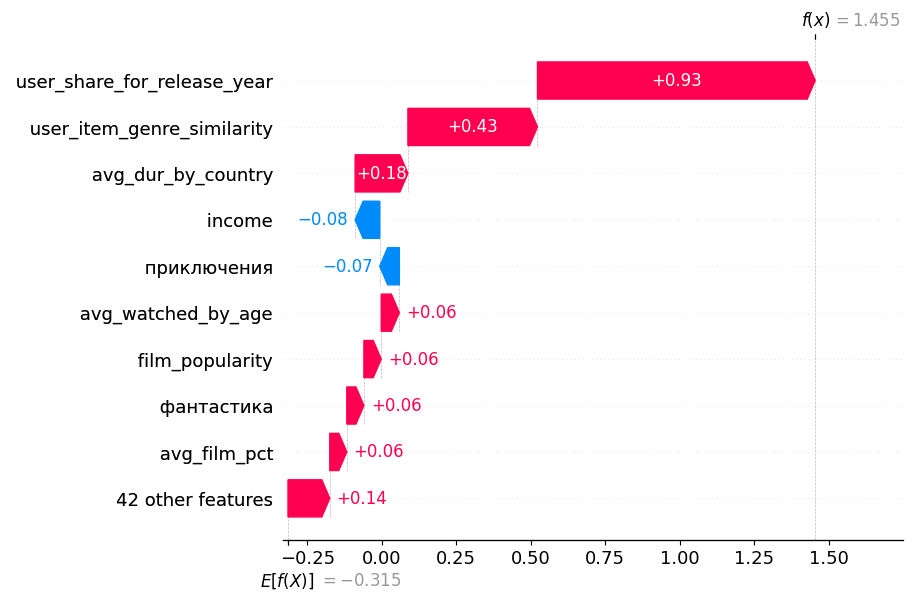

In [5]:
# feature importance для 0-го объекта
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[0], sample_df.iloc[0])

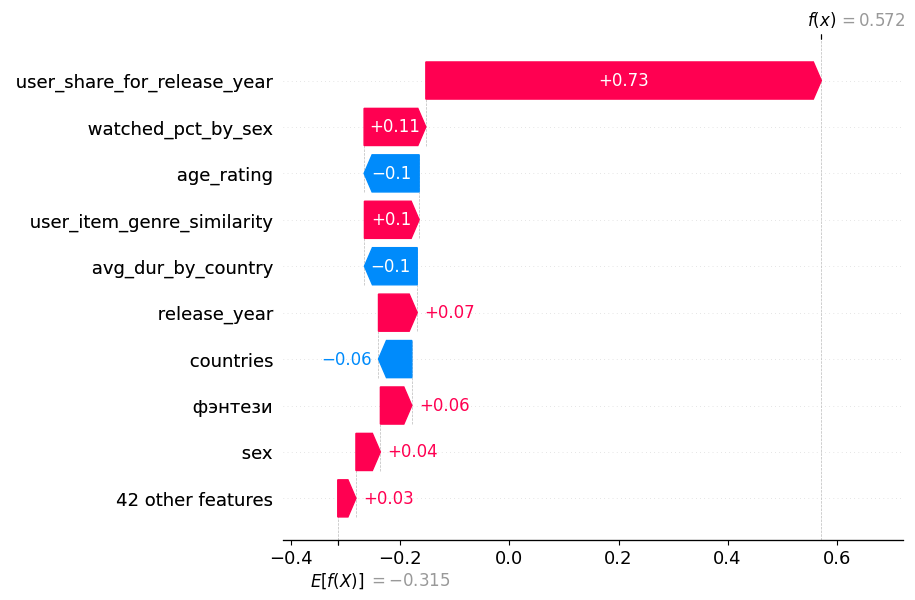

In [6]:
# feature importance для 1000-го объекта
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[999], sample_df.iloc[999])

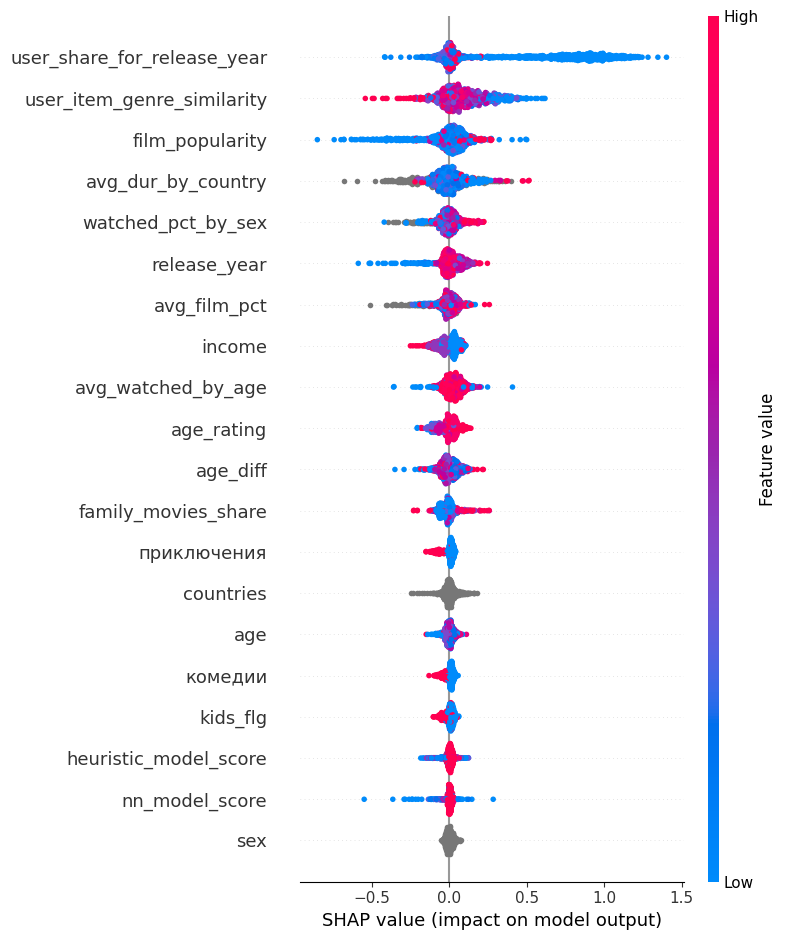

In [7]:
# влияние признаков на всех объектах подвыборки
shap.summary_plot(shap_values, sample_df, feature_names=sample_df.columns)

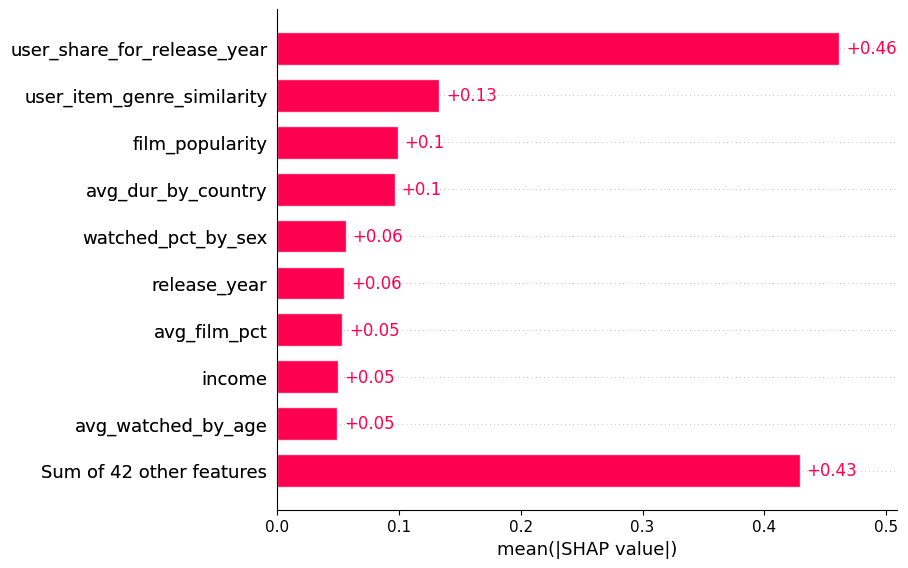

In [14]:
shap.plots.bar(explainer(sample_df))

```
Видим, что важность признаков схожа с тем, что показал встроенный метод в CatBoostClassifier, но есть и новые признаки здесь.

Наибольший вклад в прогнозирование таргета делают следующие фичи:

1. user_share_for_release_year - Историческая активность (доля фильмов) пользователя с фильмами этого года выпуска

2. user_item_genre_similarity - Совпадение любимых жанров пользователя с жанром фильма

3. film_popularity - Популярность фильма в стране пользователя (доля пользователей страны, которые его смотрели)

4. avg_dur_by_country - Средняя длительность просмотра пользователя для фильмов этой страны

```


### 4 Этап. Инференс лучшего ранкера (max 3 балла)

Теперь мы хотим построить рекомендации "на завтра", для этого нам нужно:

1. Обучить модели первого уровня на всех (train+test) данных (0.5 балла)
2. Для каждой модели первого уровня для каждого пользователя сгененировать N кандидатов (0.5 балла)
3. "Склеить" всех кандидатов для каждого пользователя (дубли выкинуть), посчитать скоры от всех моделей (0.5 балла)
4. Собрать фичи для ваших кандидатов (теперь можем считать признаки на всех данных) (0.5 балла)
5. Проскорить всех кандидатов бустингом и оставить k лучших (0.5 балла)
6. Посчитать разнообразие(Diversity) и построить график от Diversity(k) (0.5 балла)


Все гиперпараметры (N, k) определяете только Вы!

In [23]:
N = 100
k = 10

In [ ]:
# 1. Обучим модели первого уровня на всех (train+test) данных 
# + 2. Для каждой модели сгенерируем N (100) кандидатов

# объединим трейн и тест данные
full_df = pd.concat([train_df_with_features, test_df_with_features], axis=0)
need_to_drop_cols = ['item_id', 'user_id', 'heuristic_model_score',	'mf_model_score', 'nn_model_score']
full_df.drop(columns=need_to_drop_cols, inplace=True)
full_df.head()


# сгруппирую айтемы по юзерам, чтобы подать в модель TopPopular
full_df_grouped = full_df.groupby('encoded_user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x['encoded_item_id'], 
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
full_df_grouped.rename({0:'train_interactions', 'encoded_user_id': 'user_id'}, axis=1, inplace=True)

# обучим модель TopPopular
toppop_model = TopPopular()
toppop_model.fit(full_df_grouped, col='train_interactions')
toppopular_recs = toppop_model.predict(full_df_grouped, topn=N)


# создам матрицу интеракций для обучения модели iALS
interactions = df_to_matrix(full_df[['encoded_user_id', 'encoded_item_id']].rename(columns={'encoded_user_id': 'user_id', 'encoded_item_id': 'item_id'}))

# обучим модель iALS
als_model = iALS()
als_model.fit(interactions, n_iterations=5)
als_recs = pd.DataFrame(als_model.predict(top_k=N))

# обучим модель Bert4Rec
bert = BertRec(full_df, user_id_col='encoded_user_id', item_id_col='encoded_item_id', datetime_col='last_watch_dt', dataset_name='recsys_hw3_task4')
bert.fit()
bert_recs = bert.predict(topk=100)

100%|██████████| 4167/4167 [04:45<00:00, 14.57it/s]


In [98]:
# 3. "Склеить" всех кандидатов для каждого пользователя (дубли выкинуть), посчитать скоры от всех моделей

toppopular_recs['user_id'] = full_df_grouped['user_id']
toppop_pairs = toppopular_recs.melt(id_vars='user_id', value_name='item_id', var_name='heuristic_model_score')
toppop_pairs['heuristic_model_score'] = toppop_pairs['heuristic_model_score'] + 1
toppop_pairs['mf_model_score'] = None
toppop_pairs['nn_model_score'] = None

als_recs['user_id'] = full_df_grouped['user_id']
als_pairs = als_recs.melt(id_vars='user_id', value_name='item_id', var_name='mf_model_score')
als_pairs['mf_model_score'] = als_pairs['mf_model_score'] + 1
als_pairs['heuristic_model_score'] = None
als_pairs['nn_model_score'] = None


bert_pairs = bert_recs.melt(id_vars='user_id', value_name='item_id', var_name='nn_model_score')
bert_pairs['nn_model_score'] = bert_pairs['nn_model_score'] + 1
bert_pairs['heuristic_model_score'] = None
bert_pairs['mf_model_score'] = None

final_pairs = pd.concat([toppop_pairs, als_pairs, bert_pairs], axis=0).reset_index(drop=True)
# удалю дубликаты
final_pairs = final_pairs.groupby(['user_id', 'item_id'], as_index=False).agg({  
    'heuristic_model_score': 'first',
    'mf_model_score': 'first',
    'nn_model_score': 'first',
})

In [101]:
# посмотрим на данные
final_pairs.sample(5, random_state=100)

,user_id,item_id,heuristic_model_score,mf_model_score,nn_model_score
999486,791154,7632,93,None,86
640132,506183,520,None,20,None
545711,437562,5585,100,None,None
403808,322151,1452,68,None,None
934832,738235,2076,85,None,54


In [112]:
# досчитаем скоры там где у пары юзер-айтем пропуски
heuristic_model_scores = []
mf_model_scores = []
nn_model_scores = []
for i, row in tqdm.tqdm(final_pairs.iterrows()):
    if row['heuristic_model_score'] is not None:
        heuristic_model_scores.append(row['heuristic_model_score'])
    else:
        heuristic_model_scores.append(toppop_model.get_score(user_id=row['user_id'], item_id=row['item_id']))
    
    if row['mf_model_score'] is not None:
        mf_model_scores.append(row['mf_model_score'])
    else:
        mf_model_scores.append(als_model.get_score(user_id=row['user_id'], item_id=row['item_id']))

    if row['nn_model_score'] is not None:
        nn_model_scores.append(row['nn_model_score'])
    else:
        nn_model_scores.append(bert.get_score(user_id=row['user_id'], item_id=row['item_id']))

1111421it [6:41:29, 46.14it/s] 


In [ ]:
final_pairs['heuristic_model_score'] = heuristic_model_scores
final_pairs['mf_model_score'] = mf_model_scores
final_pairs['nn_model_score'] = nn_model_scores
# final_pairs.to_csv('final_pairs_task4.csv', index=False)

In [32]:
# final_pairs = pd.read_csv('final_pairs_task4.csv')
# full_df = pd.concat([train_df_with_features, test_df_with_features], axis=0)
# need_to_drop_cols = ['item_id', 'user_id', 'heuristic_model_score',	'mf_model_score', 'nn_model_score']
# full_df.drop(columns=need_to_drop_cols, inplace=True)

In [ ]:
# 4. Собрать фичи для ваших кандидатов (теперь можем считать признаки на всех данных)

final_pairs['original_user_id'] = user_le.inverse_transform(final_pairs['user_id'])
final_pairs['original_item_id'] = item_le.inverse_transform(final_pairs['item_id'])

final_pairs = final_pairs.rename(columns={'user_id': 'encoded_user_id', 'item_id': 'encoded_item_id'})
final_pairs = final_pairs.merge(items, left_on=['original_item_id'], right_on=['item_id']).merge(users, left_on=['original_user_id'], right_on=['user_id']).drop(columns=['original_item_id', 'original_user_id'])

In [ ]:
# Для этого переопределим функции, чтобы они считали статистиски по объединеному датафрейму (трейн+тест=full_df)
# + где-то делаю промежуточные агрегации, чтобы функции быстрее считались

def get_avg_watched_by_age(row):
    return age_grouped[(age_grouped['age'] == row['age'])]['watched_pct'].iloc[0]

def get_family_movies_share(row):
    return family_share_grouped[family_share_grouped['encoded_user_id'] == row['encoded_user_id']]['family_share'].iloc[0]

def get_avg_film_pct(row):
    temp = watched_pct_grouped[watched_pct_grouped['encoded_item_id'] == row['encoded_item_id']]['watched_pct']
    if len(temp) > 0:
        return temp.iloc[0]
    return 50  # медианное значение, исходя из обучающей выборки

def get_film_popularity(row):
    countries = row['countries'].split(', ')
    total_users = 0 
    if len(watched_users_grouped[(watched_users_grouped['encoded_item_id'] == row['encoded_item_id'])]['users']) > 0:
        watched_users = watched_users_grouped[(watched_users_grouped['encoded_item_id'] == row['encoded_item_id'])]['users'].iloc[0]
    else:
        return 0
    if watched_users == 0:
        return 0
    for country in countries:
        if len(users_by_country[(users_by_country['countries'] == country)]['users']) > 0:
            users = users_by_country[(users_by_country['countries'] == country)]['users'].iloc[0]
        else:
            users = 0
        total_users += users
    return watched_users / max(total_users, watched_users)

def get_user_item_genre_similarity(row):
    item_genres = row[['драмы', 'комедии', 'зарубежные',
       'мелодрамы', 'триллеры', 'русские', 'приключения', 'боевики',
       'документальное', 'криминал', 'детективы', 'фантастика', 'семейное',
       'ужасы', 'фэнтези', 'для детей', 'советские', 'военные', 'для взрослых',
       'биография', 'мультфильм', 'фитнес', 'исторические', 'спорт',
       'музыкальные', 'мультфильмы', 'мультсериалы', 'сериалы', 'историческое',
       'западные мультфильмы']]
    user_genres = user_genres_grouped[(user_genres_grouped['encoded_user_id'] == row['encoded_user_id'])][['драмы', 'комедии', 'зарубежные',
       'мелодрамы', 'триллеры', 'русские', 'приключения', 'боевики',
       'документальное', 'криминал', 'детективы', 'фантастика', 'семейное',
       'ужасы', 'фэнтези', 'для детей', 'советские', 'военные', 'для взрослых',
       'биография', 'мультфильм', 'фитнес', 'исторические', 'спорт',
       'музыкальные', 'мультфильмы', 'мультсериалы', 'сериалы', 'историческое',
       'западные мультфильмы']].iloc[0]
    return cosine_similarity([item_genres.to_list()], [user_genres.to_list()])[0][0]

def get_age_diff(row):
    return row['age'] - row['age_rating']

def get_watched_pct_by_sex(row):
    temp = watched_by_sex_grouped[(watched_by_sex_grouped['sex'] == row['sex']) & (watched_by_sex_grouped['encoded_item_id'] == row['encoded_item_id'])]['watched_pct']
    if len(temp) > 0:
        return temp.iloc[0]
    return 0

def get_user_share_for_release_year(row):
    temp = release_films_grouped[(release_films_grouped['encoded_user_id'] == row['encoded_user_id']) & (release_films_grouped['release_year'] == row['release_year'])]['films_share']
    if len(temp) > 0:
        return temp.iloc[0]
    return 0

def get_kids_similarity(row):
    kids_genres = ['для детей','мультфильм', 'мультфильмы', 'мультсериалы', 'западные мультфильмы']
    if row[kids_genres].sum() > 0 and row['kids_flg'] == 1:
        return 1
    elif row[kids_genres].sum() == 0 and row['kids_flg'] == 0:
        return 1 
    else:
        return 0

def get_avg_dur_by_country(row):
    temp = dur_by_country_grouped[(dur_by_country_grouped['encoded_user_id'] == row['encoded_user_id']) & (dur_by_country_grouped['countries'] == row['countries'])]['total_dur']
    if len(temp) > 0:
        return temp.iloc[0]
    return 0

In [57]:
age_grouped = full_df.groupby('age', as_index=False)['watched_pct'].mean()
final_pairs['avg_watched_by_age'] = final_pairs.apply(get_avg_watched_by_age, axis=1)

In [84]:
family_share_grouped = (full_df[full_df['семейное'] == 1].groupby('encoded_user_id').size() / full_df.groupby('encoded_user_id').size()).fillna(0).reset_index().rename(columns={0: 'family_share'})
final_pairs['family_movies_share'] = final_pairs.apply(get_family_movies_share, axis=1)

In [ ]:
watched_pct_grouped = full_df.groupby('encoded_item_id', as_index=False)['watched_pct'].mean()
final_pairs['avg_film_pct'] = final_pairs.apply(get_avg_film_pct, axis=1)

In [129]:
watched_users_grouped = full_df.groupby('encoded_item_id', as_index=False)['encoded_user_id'].nunique().rename(columns={'encoded_user_id': 'users'})
users_by_country = full_df.groupby('countries', as_index=False)['encoded_user_id'].nunique().rename(columns={'encoded_user_id': 'users'})
final_pairs['film_popularity'] = final_pairs.apply(get_film_popularity, axis=1)

In [136]:
user_genres_grouped = full_df.groupby('encoded_user_id', as_index=False)[['драмы', 'комедии', 'зарубежные',
       'мелодрамы', 'триллеры', 'русские', 'приключения', 'боевики',
       'документальное', 'криминал', 'детективы', 'фантастика', 'семейное',
       'ужасы', 'фэнтези', 'для детей', 'советские', 'военные', 'для взрослых',
       'биография', 'мультфильм', 'фитнес', 'исторические', 'спорт',
       'музыкальные', 'мультфильмы', 'мультсериалы', 'сериалы', 'историческое',
       'западные мультфильмы']].mean()
final_pairs['user_item_genre_similarity'] = final_pairs.apply(get_user_item_genre_similarity, axis=1)

In [140]:
final_pairs['age_diff'] = final_pairs.apply(get_age_diff, axis=1)

In [146]:
watched_by_sex_grouped = full_df.groupby(['sex', 'encoded_item_id'], as_index=False)['watched_pct'].mean()
final_pairs['watched_pct_by_sex'] = final_pairs.apply(get_watched_pct_by_sex, axis=1)

In [157]:
total_films = full_df.groupby(['encoded_user_id'], as_index=False)['encoded_item_id'].nunique().rename(columns={'encoded_item_id': 'total_films'})
release_films_grouped = full_df.groupby(['encoded_user_id', 'release_year'], as_index=False)['encoded_item_id'].nunique().rename(columns={'encoded_item_id': 'release_year_films'})
release_films_grouped = release_films_grouped.merge(total_films)
release_films_grouped['films_share'] = release_films_grouped['release_year_films'] / release_films_grouped['total_films']
final_pairs['user_share_for_release_year'] = final_pairs.apply(get_user_share_for_release_year, axis=1)

In [159]:
final_pairs['kids_similarity'] = final_pairs.apply(get_kids_similarity, axis=1)

In [167]:
dur_by_country_grouped = full_df.groupby(['encoded_user_id', 'countries'], as_index=False)['total_dur'].mean().rename(columns={'total_dur': 'avg_dur_by_country'})
# final_pairs['avg_dur_by_country'] = final_pairs.apply(get_avg_dur_by_country, axis=1) # долго, так быстрее:
final_pairs = final_pairs.merge(dur_by_country_grouped, how='left')
final_pairs['avg_dur_by_country'] = final_pairs['avg_dur_by_country'].fillna(0)

In [ ]:
# final_pairs.to_csv('final_pairs_with_features.csv', index=False)

In [39]:
# 5. Проскорить всех кандидатов бустингом и оставить k лучших

final_pairs = pd.read_csv('final_pairs_with_features.csv')
final_pairs = final_pairs[['encoded_user_id', 'encoded_item_id', 'content_type', 'release_year',
       'countries', 'age_rating', 'драмы', 'комедии', 'зарубежные',
       'мелодрамы', 'триллеры', 'русские', 'приключения', 'боевики',
       'документальное', 'криминал', 'детективы', 'фантастика', 'семейное',
       'ужасы', 'фэнтези', 'для детей', 'советские', 'военные', 'для взрослых',
       'биография', 'мультфильм', 'фитнес', 'исторические', 'спорт',
       'музыкальные', 'мультфильмы', 'мультсериалы', 'сериалы', 'историческое',
       'западные мультфильмы', 'age', 'income', 'sex', 'kids_flg',
       'avg_watched_by_age', 'family_movies_share', 'avg_film_pct',
       'film_popularity', 'user_item_genre_similarity', 'age_diff',
       'watched_pct_by_sex', 'user_share_for_release_year', 'kids_similarity',
       'avg_dur_by_country', 'heuristic_model_score', 'mf_model_score',
       'nn_model_score']]

pred  = classifier_model.predict_proba(final_pairs.drop(columns=['encoded_user_id', 'encoded_item_id']))[:, 1]
final_pairs["predicted_boosting_score"] = pred
final_pairs['original_user_id'] = user_le.inverse_transform(final_pairs['encoded_user_id'])
final_pairs['original_item_id'] = item_le.inverse_transform(final_pairs['encoded_item_id'])

In [42]:
final_recommendations = (
    final_pairs.groupby('original_user_id')
    .apply(lambda x: x.nlargest(k, 'predicted_boosting_score'))
    .reset_index(drop=True)
    .groupby('original_user_id')['original_item_id']
    .apply(list)
    .reset_index(name='final_top_k_items')
)
final_recommendations

,original_user_id,final_top_k_items
0,55,"[4779, 3467, 819, 14689, 15464, 12356, 6774, 1..."
1,681,"[8986, 4740, 591, 7225, 6162, 3734, 6809, 5536..."
2,961,"[3229, 1322, 3467, 1905, 3181, 6447, 8199, 734..."
3,1303,"[15464, 9808, 6162, 15646, 14470, 6193, 4779, ..."
4,1728,"[15464, 8986, 6447, 4779, 6162, 1517, 7343, 11..."
...,...,...
4162,1095583,"[15464, 8447, 8986, 1322, 6162, 4457, 2444, 14..."
4163,1095664,"[15464, 12356, 6162, 15648, 11348, 3363, 657, ..."
4164,1095920,"[1322, 12324, 12995, 14488, 13262, 4457, 6162,..."
4165,1096743,"[8986, 14421, 1905, 15464, 1517, 11018, 7102, ..."


In [62]:
# 6. Посчитать разнообразие(Diversity) и построить график от Diversity(k)
n_items = final_pairs['original_item_id'].max()
cutoff = 10

diversity = Diversity_MeanInterList(n_items, cutoff)

for _, row in final_recommendations.iterrows():
    diversity.add_recommendations(row['final_top_k_items'])

print(f"Diversity: {diversity.get_metric_value():.4f}")

Diversity: 0.8589


`Видим довольно высокое разнообразие полученных рекомендаций - 0.8589`

`Построим график Diversity(k)`

In [63]:
diversity_k = []
for k in tqdm.tqdm(np.arange(5, 101, 5)):
    k_recommendations = (
        final_pairs.groupby('original_user_id')
        .apply(lambda x: x.nlargest(k, 'predicted_boosting_score'))
        .reset_index(drop=True)
        .groupby('original_user_id')['original_item_id']
        .apply(list)
        .reset_index(name='final_top_k_items')
    )
    diversity = Diversity_MeanInterList(n_items, k)
    for _, row in k_recommendations.iterrows():
        diversity.add_recommendations(row['final_top_k_items'])
    diversity_k.append(diversity.get_metric_value())

100%|██████████| 20/20 [00:44<00:00,  2.20s/it]


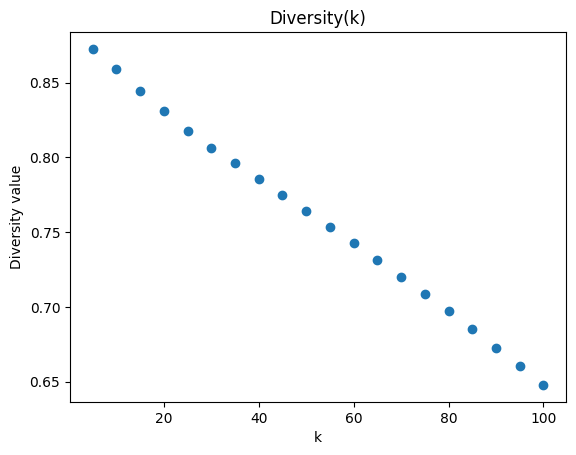

In [70]:
import matplotlib.pyplot as plt
plt.scatter(x=np.arange(5, 101, 5), y=diversity_k)
plt.title('Diversity(k)')
plt.xlabel('k')
plt.ylabel('Diversity value')
plt.show()